# Deep learning for segmentation: StarDist

This notebook is inspired by [StarDist prediction example notebook](https://github.com/stardist/stardist/blob/main/examples/2D/3_prediction.ipynb).

[StarDist](https://github.com/stardist/stardist) is a neural network that predicts for
every pixel how likely it is to be the centre of an object and what the shape of that
object is. The shape is described as a star-convex polygon: rays going from the centre
outwards to the boundary. Because a shape is predicted per object, touching nuclei come
out as separate objects. This is what is called instance segmentation.

We use a pretrained StarDist model: the network was already trained on many annotated
nuclei, and we only run the prediction from the model.

## Libraries

In [1]:
# We import the necessary libraries for plotting and image reading and processing
import matplotlib.pyplot as plt
import tifffile as tiff
import numpy as np
import skimage as sk

# We import StarDist, and the normalization helper from csbdeep, a related library for deep learning in microscopy
from stardist.models import StarDist2D
from stardist import random_label_cmap
from csbdeep.utils import normalize

# Colormap that gives every label a different random color
lbl_cmap = random_label_cmap()

I0000 00:00:1789733978.802570 2665670 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1789733978.806578 2665670 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1789733979.182994 2665670 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1789733981.161533 2665670 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONE

# Test on example data

We start with an image from the dataset the model was trained on
([DSB2018](https://github.com/stardist/stardist/releases/download/0.1.0/dsb2018.zip),
a collection of annotated nuclei). We use it first, before trying some other images.

(256, 256) uint8


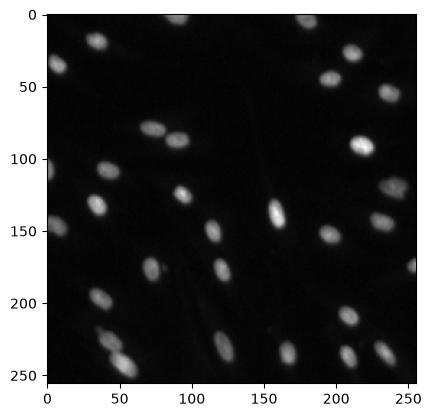

In [2]:
img_dsb = tiff.imread("data/stardist_example1.tif")
print(img_dsb.shape, img_dsb.dtype)

_ = plt.imshow(img_dsb, cmap="gray")

## Loading a pretrained model

StarDist ships with a few pretrained models. Calling `from_pretrained()` without
arguments prints the list.

In [3]:
# Show which pretrained models are available
StarDist2D.from_pretrained()

There are 4 registered models for 'StarDist2D':

Name                  Alias(es)
────                  ─────────
'2D_versatile_fluo'   'Versatile (fluorescent nuclei)'
'2D_versatile_he'     'Versatile (H&E nuclei)'
'2D_paper_dsb2018'    'DSB 2018 (from StarDist 2D paper)'
'2D_demo'             None


We pick the 2D_versatile_fluo model, which is trained on a variety of fluorescent images. It will download the model from the internet if it is not already present on your computer.


In [4]:
model = StarDist2D.from_pretrained("2D_versatile_fluo")

Found model '2D_versatile_fluo' for 'StarDist2D'.


E0000 00:00:1789733982.999149 2665670 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Loading network weights from 'weights_best.h5'.
Loading thresholds from 'thresholds.json'.
Using default values: prob_thresh=0.479071, nms_thresh=0.3.


In [5]:
# If you get an error above on winows try this
import shutil, tempfile
from pathlib import Path

for base in [Path.home() / ".keras", Path(tempfile.gettempdir()) / ".keras"]:
    d = base / "models" / "StarDist2D" / "2D_versatile_fluo"
    src, dst = d / "2D_versatile_fluo_extracted", d / "2D_versatile_fluo"
    if src.is_dir() and not dst.exists():
        shutil.copytree(src, dst)
        print("copied to", dst)


## Normalization

The network was trained on images whose intensities were scaled between 0-1.
If we feed it raw microscope images, which are either 0-255 for 8-bit or 0-65535 for a 16-bit image
the numbers are far outside the range the model has ever seen, and the predictions get worse.

We run a normalization function to scale the image between 0 and 1.
`normalize(img, 1, 99.8)` sets the 1st percentile of the intensities to 0 and the
99.8th percentile to 1. We use percentiles instead of the minimum and maximum so
that a handful of bright pixels do not affect the normalization.
The values are not clipped, so the brightest pixels end up slightly above 1.

In [6]:
img_dsb_norm = normalize(img_dsb, 1, 99.8)

print(f"before normalization: {img_dsb.min()} to {img_dsb.max()}")
print(f"after normalization: {img_dsb_norm.min():.2f} to {img_dsb_norm.max():.2f}")

before normalization: 1 to 127
after normalization: -0.01 to 1.33


## Predicting the nuclei

`predict_instances()` runs the network and turns its output into objects. It returns
two things:

- `labels`: an image the same size as the input, with 0 for background and
  1, 2, 3, ... for the individual nuclei, the same kind of label image that
  `skimage.measure.label()` gave us on day 1
- `details`: the polygon coordinates and the probability of each detected object

In [21]:
labels, details = model.predict_instances(img_dsb_norm)

print(f"found {labels.max()} nuclei")
print(f"details contains: {list(details.keys())}")

found 29 nuclei
details contains: ['coord', 'points', 'prob']


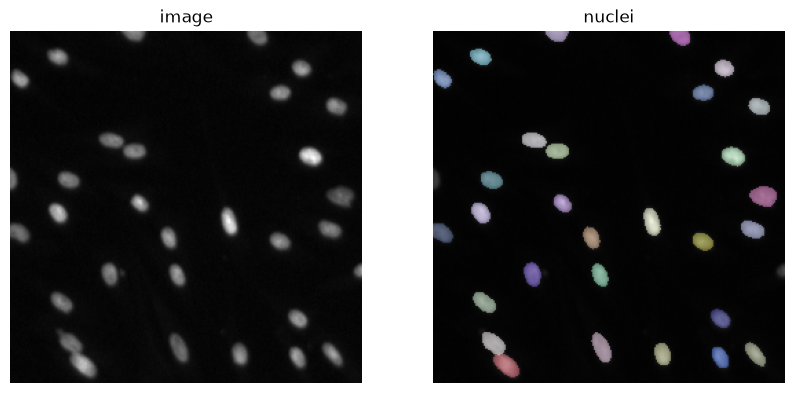

In [22]:
#Let's visualize the results.
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
# The raw image
_ = axs[0].imshow(img_dsb, cmap="gray")
_ = axs[0].set_title("image")
# The same image with the labels on top
_ = axs[1].imshow(img_dsb, cmap="gray")
_ = axs[1].imshow(labels, cmap=lbl_cmap, alpha=0.5)
_ = axs[1].set_title("nuclei")
for ax in axs:
    _ = ax.axis("off")

## What does StarDist predict?

`details` holds what the network predicted for each object:

- `points`: the centre of each object
- `coord`: the end points of the rays, which together form the polygon outline
- `prob`: how sure the network is that this is an object

Below we draw the polygons on the image. With `show_dist=True` the rays from
the centre to the boundary are drawn as well.

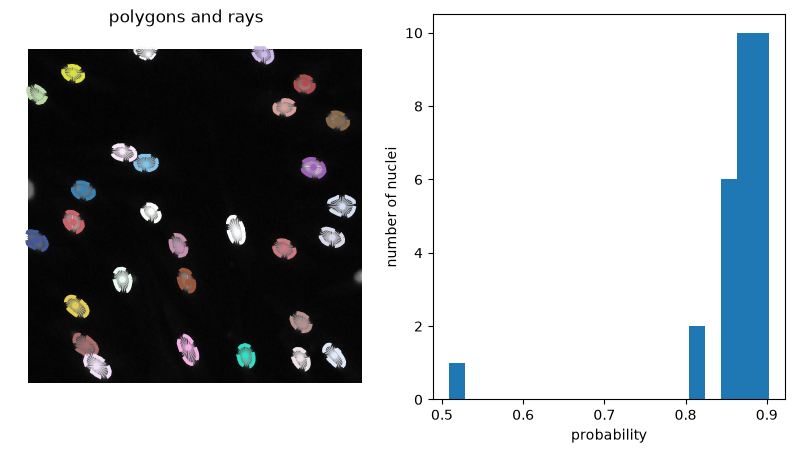

In [23]:
from stardist import _draw_polygons

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
# Polygons and rays predicted for every nucleus
_ = axs[0].imshow(img_dsb, cmap="gray")
plt.sca(axs[0])  # _draw_polygons draws on the current axes
_draw_polygons(details["coord"], details["points"], details["prob"], show_dist=True)
_ = axs[0].set_title("polygons and rays")
_ = axs[0].axis("off")
# Probability of every detected nucleus
_ = axs[1].hist(details["prob"], bins=20)
_ = axs[1].set_xlabel("probability")
_ = axs[1].set_ylabel("number of nuclei")

# Let's try with some other images

We have a few images from an experiment on DNA damage. Cells were either irradiated (`IR`)
or left untreated (`control`), fixed 2 hours later, and imaged in two channels:

- channel 0: DNA damage foci (anti-RAD51 antibody) the bright dots inside the nuclei
- channel 1: the nuclei (DAPI)

For now we only use the nuclei channel. We will later try to also detect the foci,
where we count how many of them sit in each nucleus.

(2, 1024, 1024)


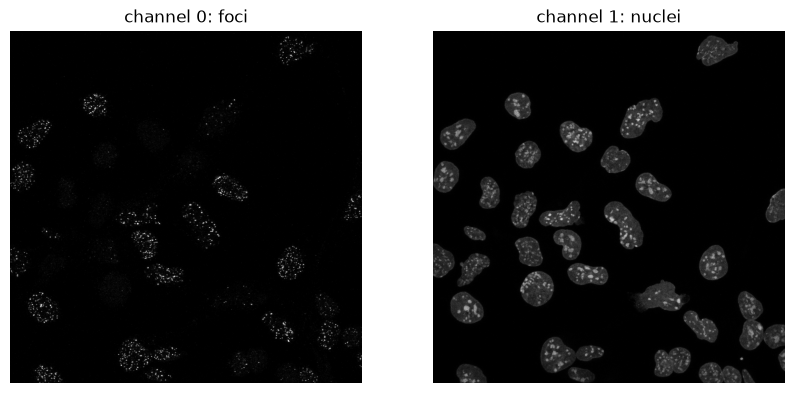

In [33]:
img = tiff.imread("data/MAX_2h_IR_Position002.tif")
print(img.shape)

# Split the two channels
img_foci   = img[0, :, :]
img_nuclei = img[1, :, :]

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
_ = axs[0].imshow(img_foci, cmap="gray")
_ = axs[0].set_title("channel 0: foci")
_ = axs[1].imshow(img_nuclei, cmap="gray")
_ = axs[1].set_title("channel 1: nuclei")
for ax in axs:
    _ = ax.axis("off")

The foci in the first channel are not very clear to see. You could check the maximum intensity in the image with `img_foci.max()`.
Then you could use the argument `vmax=50` at the right place in the code above.

## A first attempt

Let us do exactly what we did before: normalize, then predict.

found 238 nuclei


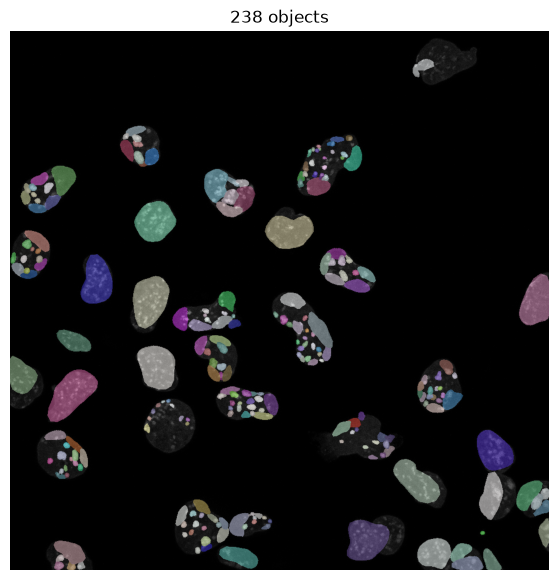

In [34]:
img_nuclei_norm = normalize(img_nuclei, 1, 99.8)

labels_naive, _ = model.predict_instances(img_nuclei_norm)
print(f"found {labels_naive.max()} nuclei")

_ = plt.figure(figsize=(7, 7))
_ = plt.imshow(img_nuclei, cmap="gray")
_ = plt.imshow(labels_naive, cmap=lbl_cmap, alpha=0.5)
_ = plt.title(f"{labels_naive.max()} objects")
_ = plt.axis("off")

## Improving the result

That is far too many objects, the results show that single nuclei are cut into
several pieces.

The reason is the size of the nuclei. The network learned what a nucleus looks like at the pixel size of
its training images, where nuclei are a few tens of pixels across. We can compare that with the image above from the training data.
Our nuclei are around 80 pixels across. Inside the nuclei are nucleoli and those are more the size the model expects.

So we will show the image to the network at a smaller scale. `predict_instances()` has a
`scale` argument for this: it downscales the image, predicts, and converts the labels back
onto the original pixel grid, so `labels` has the same shape as the input image.

In [35]:
labels, details = model.predict_instances(img_nuclei_norm, scale=0.5)

print(f"found {labels.max()} nuclei")
print(f"label image shape: {labels.shape}  (same as the input: {img_nuclei.shape})")

found 38 nuclei
label image shape: (1024, 1024)  (same as the input: (1024, 1024))


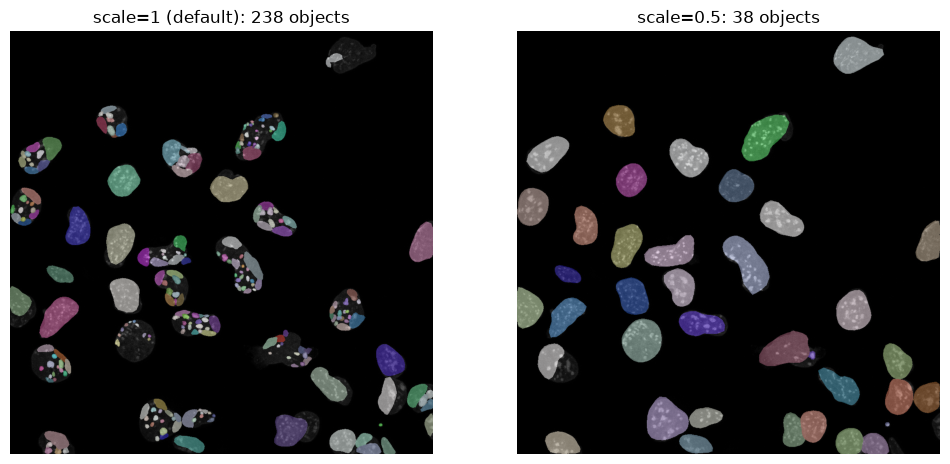

In [36]:
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
# Prediction at the original scale
_ = axs[0].imshow(img_nuclei, cmap="gray")
_ = axs[0].imshow(labels_naive, cmap=lbl_cmap, alpha=0.5)
_ = axs[0].set_title(f"scale=1 (default): {labels_naive.max()} objects")
# Prediction on the downscaled image
_ = axs[1].imshow(img_nuclei, cmap="gray")
_ = axs[1].imshow(labels, cmap=lbl_cmap, alpha=0.5)
_ = axs[1].set_title(f"scale=0.5: {labels.max()} objects")
for ax in axs:
    _ = ax.axis("off")

## Exercise: What happens if you do not normalize?

Run `predict_instances()` on `img_nuclei` without normalizing it first (keep
`scale=0.5`), and plot the result next to the normalized one.

- How many objects do you get?
- Which objects did it find instead of the nuclei?

## Exercise: Which scale works best?

We picked `scale=0.5` without checking. Try a few values (for example 0.25, 0.4, 0.5,
0.75).
You could try and plot the number of detected objects against the scale.

- Which scale gives a sensible result in the overlay?
- You could try to load another image of the data set and check that image as well.

# Next

We now have nuclei as a label image. 
In the next notebook we do the same job with **Cellpose**, which uses a different trick to
find objects and asks for the object size in a different way.

# Extra: multiplex image

Here we explore how to use StarDist on large 2D images. For example with this multiplex image provided as example in the [QuPath](https://qupath.readthedocs.io/en/stable/) software.

Download the file `LuCa-7color_[13860,52919]_1x1component_data.tif` from
https://downloads.openmicroscopy.org/images/Vectra-QPTIFF/perkinelmer/PKI_fields/
Save it in the data folder.

In [14]:
luca = tiff.imread("data/LuCa-7color_[13860,52919]_1x1component_data.tif")
print(luca.shape)

(8, 1400, 1868)


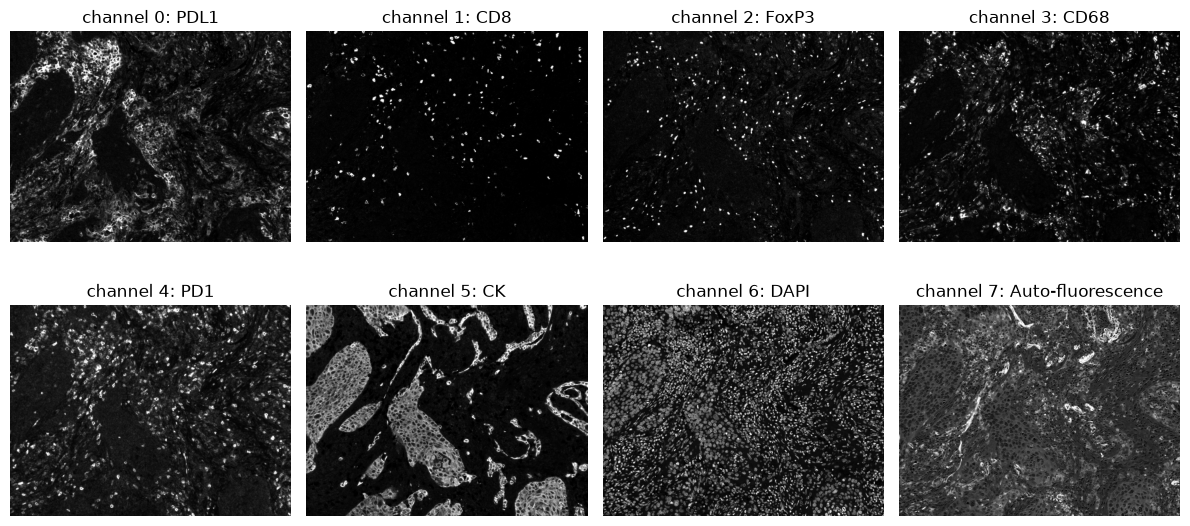

In [15]:
channel_names = [
    "PDL1", "CD8", "FoxP3", "CD68",
    "PD1", "CK", "DAPI", "Auto-fluorescence"
]

fig, axs = plt.subplots(2, 4, figsize=(12, 6))
axs = axs.ravel()

for i, name in enumerate(channel_names):
    axs[i].imshow(
        luca[i, ...], # looking at the shape of the luca array, we see that the first dimension is the channel dimension, so we index it with i to get the ith channel
        cmap="gray",
        vmax=np.percentile(luca[i, ...], 99.5)
    )
    axs[i].set_title(f"channel {i}: {name}")
    axs[i].axis("off")

plt.tight_layout()

Running stardist or any other AI model on large images (either 2D or 3D) can consume a lot more computer memory and often cannot be done at once. 
We can therefore split the image up into pieces. We create the label maps of the separate 'tiles' with some overlap and put them together again in the end. In StarDist this is done with the `n_tiles` argument.

In [37]:
labels, details = model.predict_instances(normalize(luca[6, ...], 1, 99.8), scale=1, n_tiles=[4, 4])

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 16/16 [00:02<00:00,  7.96it/s]


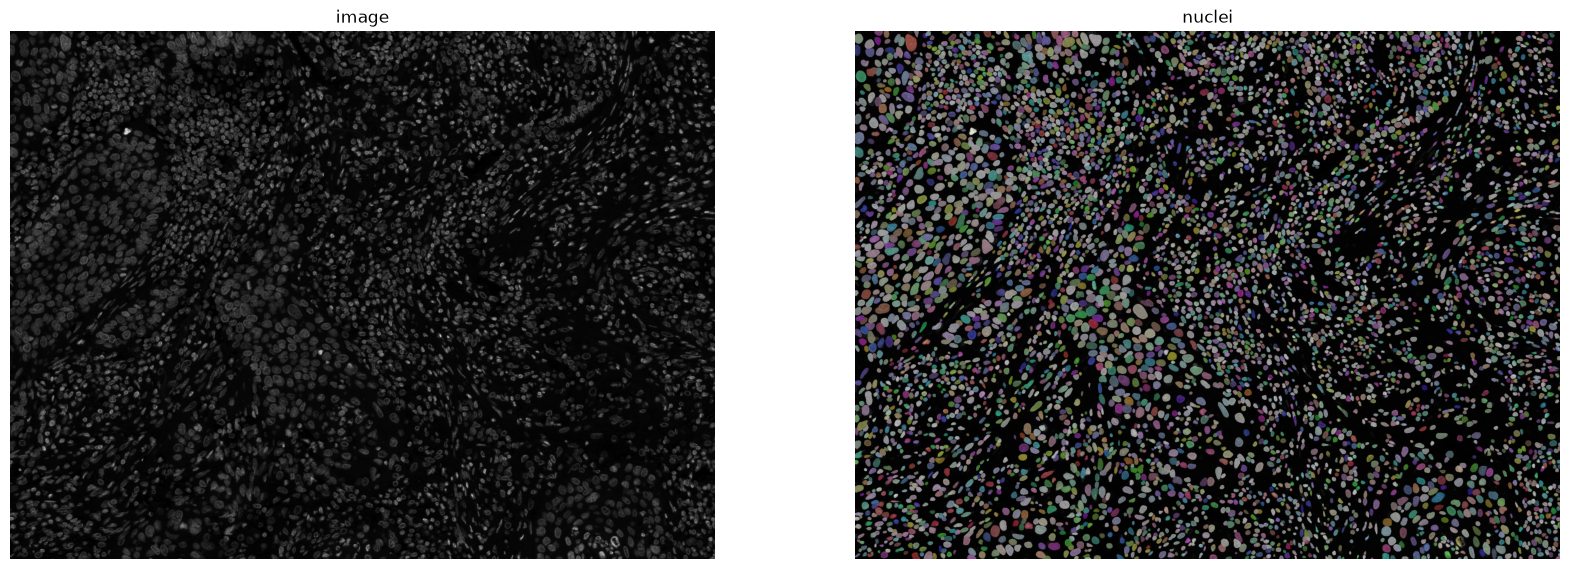

In [38]:
#Let's visualize the results.
fig, axs = plt.subplots(1, 2, figsize=(20, 10))
# The raw image
_ = axs[0].imshow(luca[6, ...], cmap="gray")
_ = axs[0].set_title("image")
# The same image with the labels on top
_ = axs[1].imshow(luca[6, ...], cmap="gray")
_ = axs[1].imshow(labels, cmap=lbl_cmap, alpha=0.5)
_ = axs[1].set_title("nuclei")
for ax in axs:
    _ = ax.axis("off")

As you can see some of the proteins in the channels above is in the cytoplasm. If we want to measure the intensity in the cytoplasm we could do something what is call label expansion. We expand the label with a certain radius or until it touches another cell. Scikit image does have a function called `expand_labels()`. 
Subsequently we can substract the nuclear labels from the image to get only the cytoplasmic signal.

In [39]:
# expand labels and define cytoplasm mask
from skimage.segmentation import expand_labels 
expanded_labels = expand_labels(labels, distance=10)
# cytoplasm mask is defined as the expanded labels minus the original labels
cytoplasm_mask = expanded_labels - labels

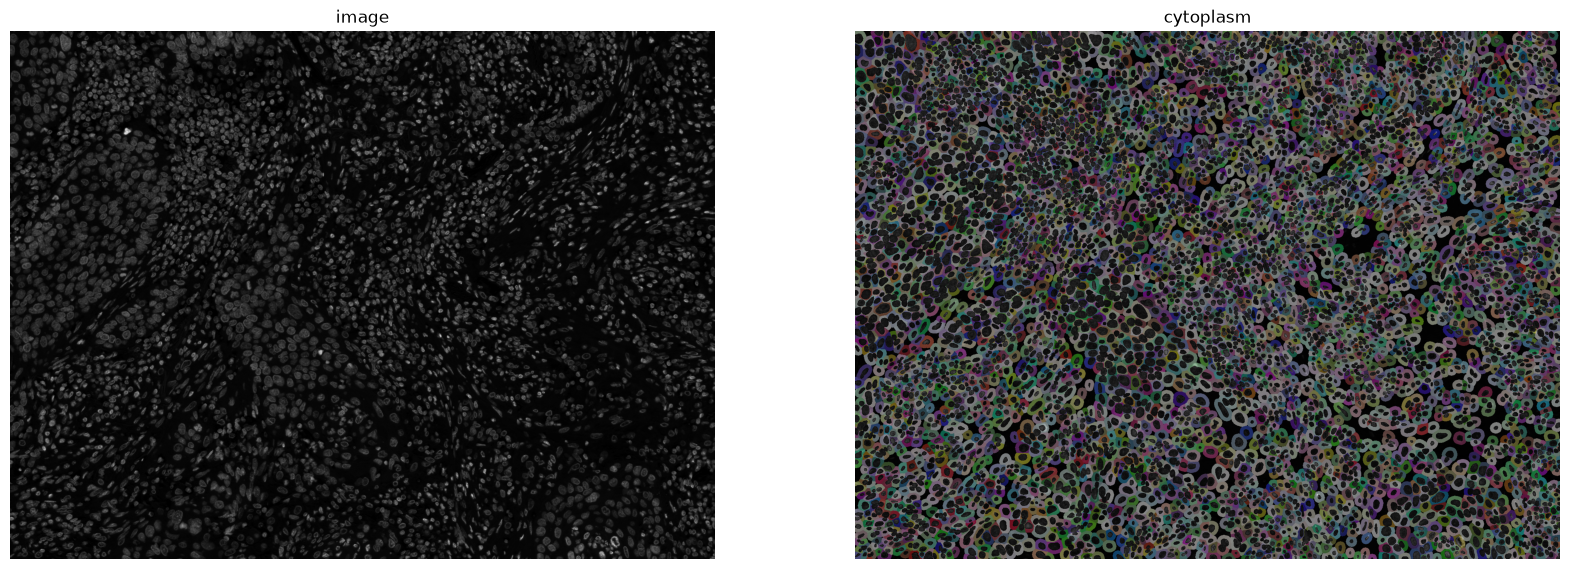

In [40]:
#Let's visualize the results.
fig, axs = plt.subplots(1, 2, figsize=(20, 10))
# The raw image
_ = axs[0].imshow(luca[6, ...], cmap="gray")
_ = axs[0].set_title("image")
# The same image with the labels on top
_ = axs[1].imshow(luca[6, ...], cmap="gray")
_ = axs[1].imshow(cytoplasm_mask, cmap=lbl_cmap, alpha=0.5)
_ = axs[1].set_title("cytoplasm")
for ax in axs:
    _ = ax.axis("off")

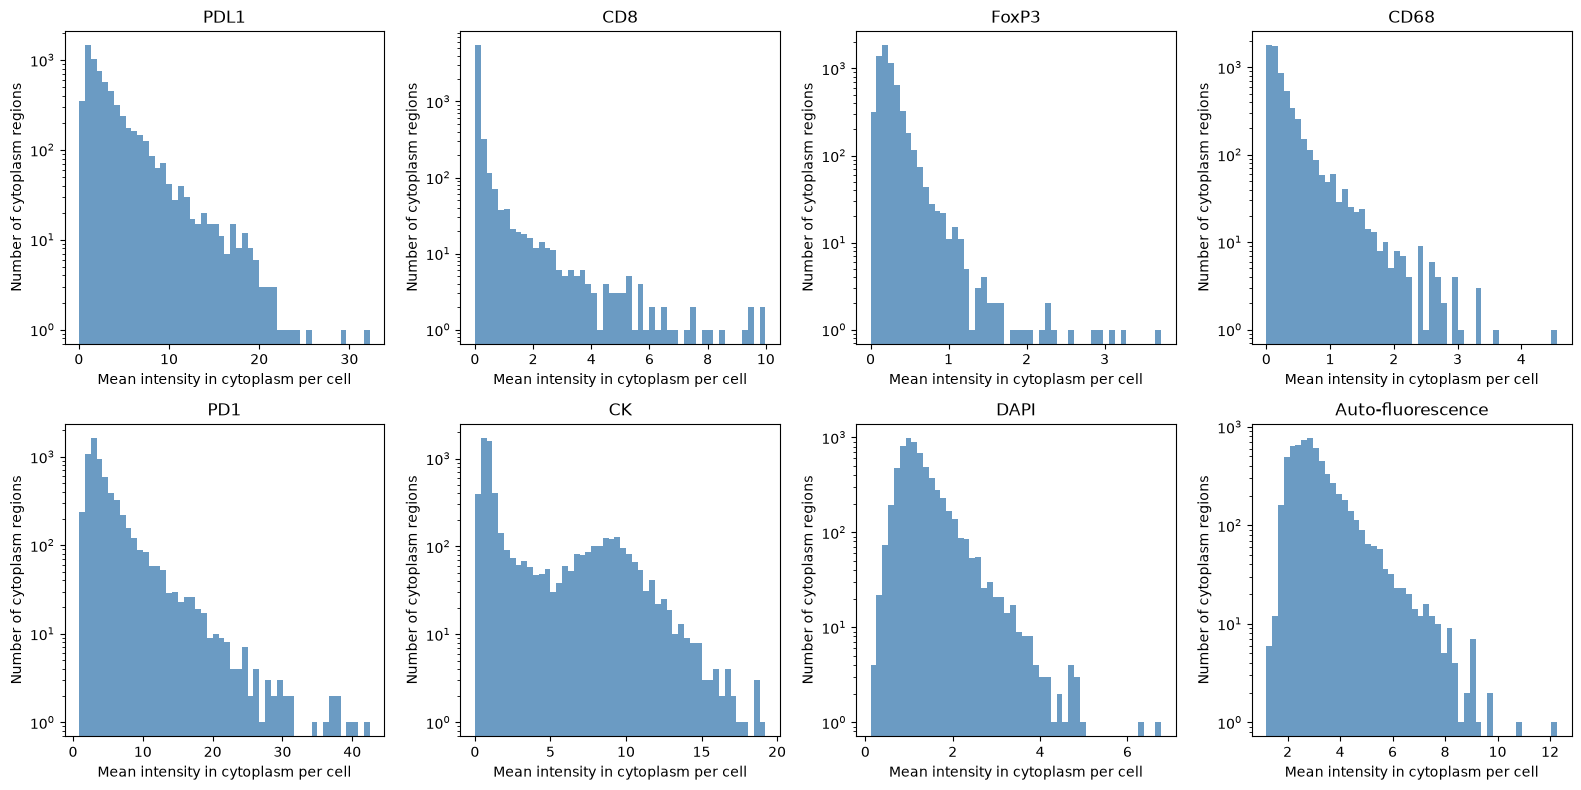

In [20]:
# Measure marker intensities in the cytoplasm ring around each nucleus
marker_measurements = {}

for channel, marker in enumerate(channel_names):
    props = sk.measure.regionprops_table(
        cytoplasm_mask,
        intensity_image=luca[channel],
        properties=("label", "area", "mean_intensity", "max_intensity"),
    )
    marker_measurements[marker] = props

# Plot the distribution of mean marker intensities per cell
fig, axs = plt.subplots(2, 4, figsize=(16, 8))
axs = axs.ravel()

for ax, marker in zip(axs, channel_names):
    values = marker_measurements[marker]["mean_intensity"]
    ax.hist(values, bins=50, color="steelblue", alpha=0.8)
    ax.set_title(marker)
    ax.set_xlabel("Mean intensity in cytoplasm per cell")
    ax.set_ylabel("Number of cytoplasm regions")
    ax.set_yscale("log")

plt.tight_layout()

Note: If you would like to explore this further you could also download an H&E image from the link above. StarDist also has a model that can segment nuclei from brightfield images.

This analysis is done with an image of 80 MB, however when images get much larger we should think of ways to not store all data in the computer memory at once, for example by storing data in `OME-zarr` format. This helps to only read the part of the data that we need at that moment or using the `dask` library to manage the loading of the data in an efficient way. 

Here is a notebook that shows these options:
https://github.com/stardist/stardist/blob/main/examples/other2D/predict_big_data.ipynb

**3D?** StarDist also has models for 3D data. You can explore the possibilities here:
https://github.com/stardist/stardist/tree/main/examples